In [4]:
# set auto-reload of the notebook
%load_ext autoreload
%autoreload 2

import cns
import cns.data_utils as cdu
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 10)
# set color_map to tab10
color_map = plt.cm.get_cmap('tab10').colors[:10]
plt.rcParams.update({'font.size': 12})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


C:\Users\adams\AppData\Local\Temp\ipykernel_34920\1736925853.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab10').colors[:10]


In [20]:
cns_dfs = {}
for grouping in ["arms", "20MB", "5MB", "2MB", "500KB"]:
	print(f"Loading {grouping}...")
	samples_df, cns_df = cdu.main_load(grouping)
	cns.only_aut(cns_df, inplace=True)
	cns.add_total_cn(cns_df, inplace=True)
	cns_dfs[grouping] = cns_df
samples_df["type"].value_counts().head()

Loading arms...
Loading 20MB...
Loading 5MB...
Loading 2MB...
Loading 500KB...


type
LUAD    1314
BRCA    1157
LUSC     996
OV       618
PRAD     563
Name: count, dtype: int64

In [21]:
cosmic = cdu.load_COSMIC()
cosmic_df = cns.segments_to_cns_df(cosmic)[["chrom", "start", "end", "name"]].rename(columns={"name": "gene"})
ensembl = cdu.load_ENSEMBL()
cancer_type = "LUSC"
val_count = 3

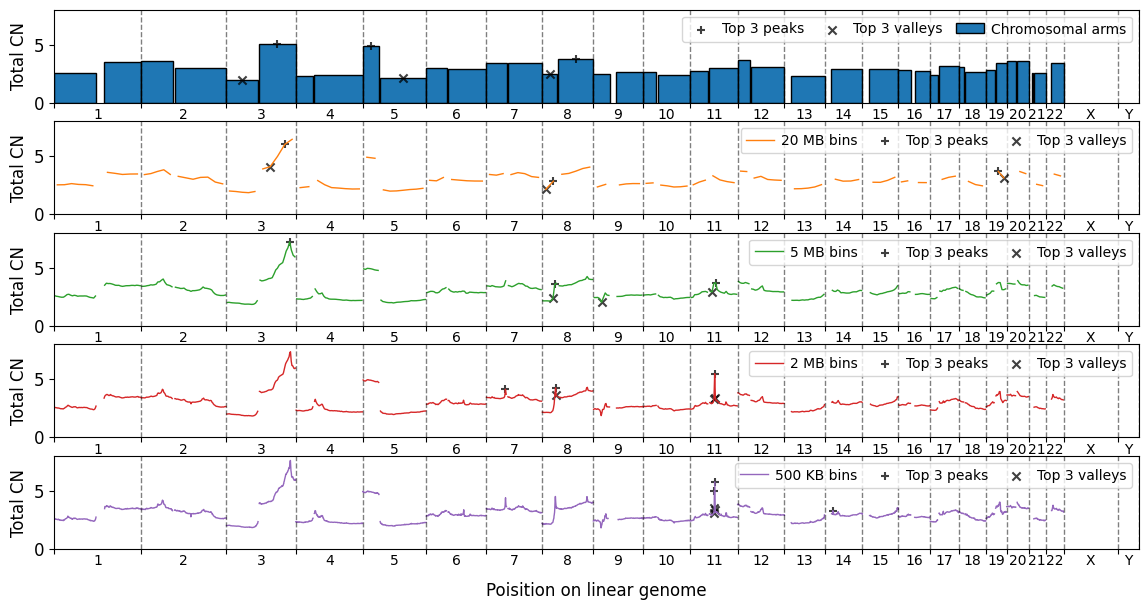

In [30]:
fig, axs = plt.subplots(len(cns_dfs), 1, figsize=(14, 7))

def get_grouping_name(grouping):
	if grouping == "whole":
		return "Whole genome"
	elif grouping == "arms":
		return "Chromosomal arms"
	elif grouping == "20MB":
		return "20 MB bins"
	elif grouping == "5MB":
		return "5 MB bins"
	elif grouping == "2MB":
		return "2 MB bins"
	elif grouping == "500KB":
		return "500 KB bins"
	else:
		raise ValueError(f"Unknown grouping: {grouping}")

for i, (grouping, cns_df) in enumerate(cns_dfs.items()):
	sel_df = cns.select_cns_by_type(cns_df, samples_df, cancer_type) if cancer_type != "all" else cns_df
	group_df = cns.group_samples(cns.only_aut(cns.add_total_cn(sel_df)))
	group_df["sample_id"] = f"mean {cancer_type} CN"
	group_df = cns.add_cum_mid(group_df)
	if grouping == "whole":
		group_by = "sample"
	elif grouping == "arms":
		group_by = "chrom"
	else:
		group_by = "cons"
	group_df["score"] = cns.calc_angles(group_df, "total_cn", group_by=group_by)

	if grouping == "whole" or grouping == "arms":

		cns.plot_bars(axs[i], group_df, cn_column="total_cn", color=color_map[i], label=f"{get_grouping_name(grouping)}")
	else:
		cns.plot_lines(axs[i], group_df, cn_column="total_cn", color=color_map[i],  label=f"{get_grouping_name(grouping)}")
	cns.plot_x_lines(axs[i])
	cns.plot_x_ticks(axs[i])

	group_df = group_df.sort_values(by="score", ascending=False)
	axs[i].scatter(group_df["cum_mid"].head(val_count), group_df["total_cn"].head(val_count), color="k", alpha=0.75, s=35, label=f"Top {val_count} peaks", marker="+")
	axs[i].scatter(group_df["cum_mid"].tail(val_count), group_df["total_cn"].tail(val_count), color="k", alpha=0.75, s=35, label=f"Top {val_count} valleys", marker="x")
	axs[i].set_ylim(0, 8)
	axs[i].set_ylabel("Total CN")
	axs[i].legend(loc="upper right", ncol=3, fontsize=10, handletextpad=0.5, columnspacing=1)

axs[-1].set_xlabel("Poisition on linear genome")

cdu.save_cns_fig(f"fig_peaks_valleys_{cancer_type}")

In [9]:
score_means = []

def get_gouping_type(bins):
	if bins == "whole":
		return "sample"
	elif bins == "arms":
		return "chrom"
	else:
		return "cons"

for i, (grouping, cns_df) in enumerate(cns_dfs.items()):
	print(f"Loading {grouping}...")
	sel_df = cns.select_cns_by_type(cns_df, samples_df, cancer_type) if cancer_type != "all" else cns_df
	sel_df = cns.group_samples(cns.only_aut(cns.add_total_cn(sel_df)))
	sel_df["sample_id"] = f"mean {cancer_type} CN"
	sel_df["score"] = cns.calc_angles(sel_df, "total_cn", get_gouping_type(grouping))	
	score_means.append(cns.mean_value_per_seg(sel_df, ensembl, "score"))

mean_dfs = {}
mean_df = score_means[0].copy()
for vals in score_means[1:]:
	mean_df["score"] += vals["score"]
mean_df["score"] /= len(score_means)
mean_df["total_cn"] = cns.mean_value_per_seg(sel_df, ensembl, "total_cn")["total_cn"]
mean_df = pd.merge(mean_df, cosmic_df, how="left")

cns.save_cns(mean_df, cdu.pjoin(cdu.out_path, f"gene_scores_{cancer_type}.tsv"))

Loading arms...
Loading 20MB...
Loading 5MB...
Loading 2MB...
Loading 250KB...


In [10]:
print(mean_df[~mean_df["gene"].isna()].sort_values(by="score", ascending=False).head(10))

       chrom      start        end             name     score  total_cn  \
17294   chr7   55086713   55324313  ENSG00000146648  0.426312  4.418679   
18498   chr8  128747679  128753674  ENSG00000136997  0.321764  3.975192   
3691   chr11   69455854   69469242  ENSG00000110092  0.318442  3.593908   
8252   chr17   37844166   37886679  ENSG00000141736  0.301957  3.296131   
3698   chr11   70049268   70053496  ENSG00000168040  0.280958  3.437112   
4824   chr12   69201955   69239214  ENSG00000135679  0.256590  3.440343   
8255   chr17   37921197   38020441  ENSG00000161405  0.245090  3.176233   
18451   chr8  117858173  117887105  ENSG00000164754  0.220087  3.622083   
18455   chr8  118806728  119124092  ENSG00000182197  0.218834  3.632654   
18406   chr8  101698043  101735037  ENSG00000070756  0.215936  3.581757   

         gene  
17294    EGFR  
18498     MYC  
3691    CCND1  
8252    ERBB2  
3698     FADD  
4824     MDM2  
8255    IKZF3  
18451   RAD21  
18455    EXT1  
18406  PABPC1 

In [11]:
print(mean_df.sort_values(by="score", ascending=False).head(10))

       chrom      start        end             name     score  total_cn   gene
17294   chr7   55086713   55324313  ENSG00000146648  0.426312  4.418679   EGFR
3689   chr11   68816364   68858072  ENSG00000162341  0.328185  3.259999    NaN
18498   chr8  128747679  128753674  ENSG00000136997  0.321764  3.975192    MYC
3690   chr11   69061604   69182494  ENSG00000172927  0.320878  2.047882    NaN
17301   chr7   56019511   56024192  ENSG00000239789  0.320461  3.509957    NaN
17299   chr7   55955168   56009918  ENSG00000178665  0.320461  3.509957    NaN
17298   chr7   55954969   56022932  ENSG00000249773  0.320461  3.509957    NaN
17297   chr7   55861236   55930482  ENSG00000154997  0.320461  3.509957    NaN
3692   chr11   69467843   69490184  ENSG00000149716  0.318442  3.593908    NaN
3691   chr11   69455854   69469242  ENSG00000110092  0.318442  3.593908  CCND1


We therefore focused on relative effects: when applied to the COSMIC gene set (i.e. where cancer effect is already expected), our method determines the top 5 genes to be FADD (OS=1.53), CCND1 (OS=1.22), FGFR1 (OS=0.94), SOX2 (OS=0.65), and EGFR (OS=0.46). 

In [12]:

ordered_df = mean_df.sort_values(by=["score"], ascending=False)
ordered_df["score"].sum()
tsgs_df = ordered_df.query("score < 0")[["chrom", "start", "end", "name", "score"]].copy()
tsgs_df["score"] = -tsgs_df["score"]
print(tsgs_df["score"].describe())
print(tsgs_df["score"].sum())
tsgs_df.to_csv(cdu.pjoin(cdu.out_path, f"tsgs_cnsistent_all.tsv"), sep="\t", index=False, header=False)
tsgs_df[-1000:].to_csv(cdu.pjoin(cdu.out_path, f"tsgs_cnsistent_1000.tsv"), sep="\t", index=False, header=False)

ogs_df = ordered_df.query("score >= 0")[["chrom", "start", "end", "name", "score"]].copy()
print(ogs_df["score"].describe())
print(ogs_df["score"].sum())
# ogs_df["score"] = ogs_df["score"] / ogs_df["score"].sum() * tsgs_df["score"].sum()
# print(ogs_df["score"].describe())
# print(ogs_df["score"].sum())
ogs_df.to_csv(cdu.pjoin(cdu.out_path, f"ogs_cnsistent_all.tsv"), sep="\t", index=False, header=False)
ogs_df[:1000].to_csv(cdu.pjoin(cdu.out_path, f"ogs_cnsistent_1000.tsv"), sep="\t", index=False, header=False)

count    10309.000000
mean         0.062873
std          0.051923
min          0.000006
25%          0.023691
50%          0.043074
75%          0.103306
max          0.260112
Name: score, dtype: float64
648.1590601493838
count    9121.000000
mean        0.066429
std         0.059468
min         0.000028
25%         0.015671
50%         0.047474
75%         0.113112
max         0.426312
Name: score, dtype: float64
605.8983195887258
